In [1]:
from rustyspikes import *
np.random.seed(42)
import random

# res = .5
def keep_scale(scale, lr, synapses):
    for i in synapses:
        i.scale = scale
        i.lr = lr

[500]
[500]
[500]
[500, 0, 411, 52, 433, 469, 88, 499, 465]


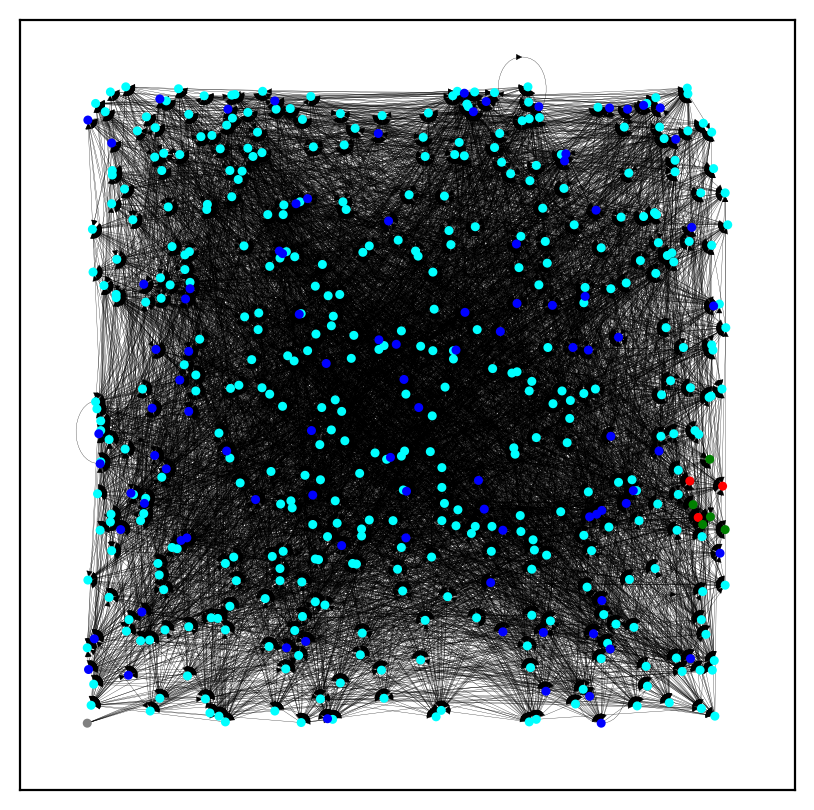

In [ ]:
model = SNNModel()
ne = 400
ni = 100
ns = 15
n_stimulated = 7
model.generate_network_local_connections(num_exc = ne, num_inh=ni, num_syn=ns, coords_dim=1000, max_delay=500, starting_delay=(100,300), strict=True)
# model.generate_network_local_connections_no_delays(num_exc = ne, num_inh=ni, num_syn=ns, coords_dim=1000, weights=(.4,.7), max_inputs=ns)
model.add_neuron(Spikes_at_will(awaiting_time = 0, refresh_time=100, id=ne+ni, coords=[0,0], color='grey', synaptic_limit=1))
# model.set_d_lr(100)
model.set_lr_to_all(.1)
closest = model.find_n_nearest(0,n_stimulated)
print(model.get_sources())
print(model.get_deadends())
print(model.get_outsiders())

# model.add_synapse(Delayed_synapse(model[ne+ni], model[0], max_delay=100, d_lr=0, b=8.6, w=2)) #delayed
receiver = Synapse(model[ne+ni], model[0], max_delay=100, lr=0)
model.add_synapse(receiver) #stdp
model.obj0.append(receiver)

for i in closest:
    receiver = Synapse(model[ne+ni], model[i], max_delay=100, lr=0)
    # receiver = Delayed_synapse(model[ne+ni], model[i], max_delay=100, d_lr=0, b=8.6, w=2) #delayed
    model.add_synapse(receiver) #stdp
    model.obj0.append(receiver)
    if i > ne:
        model[i].color = 'green'
    else:
        model[i].color = 'red'
model.reload_graph()
G = model.get_graph()
highlight_nodes = [ne+ni, 0, *closest]
colors = []
model[0].color = 'red'
for i in model.neurons.keys():
    colors.append(model[i].color)
# for i in model.neurons.keys():
#     if i in highlight_nodes:
#         colors.append('red')
#         if i >= ne:
#             colors[i] = 'green'
#     else:
#         if i < ne:
#             colors.append('cyan')
#         else:
#             colors.append('blue')
colors[ne+ni] = 'gray'
pos=nx.get_node_attributes(G,'pos')
print(highlight_nodes)
plt.figure(dpi=200, figsize=(5, 5))
nx.draw_networkx(G, pos, node_size=5, width=.1, arrowsize=5, node_color=colors, with_labels=False, font_size=6, font_color='green', font_weight=10)

In [3]:
print(model.get_name())

local_e400i100s30ms30stdp__0.rspks


In [ ]:
model_name = 'local_e400i100s30ms30stdp__0.rspks'
# model_name = model.get_name()
# save_model(model, f'models/{model_name}')

Loaded the following model:
local_e400i100s30ms30stdp__0.rspks
501 15008
[500, 0, 274, 80, 20, 479, 231, 213, 181]


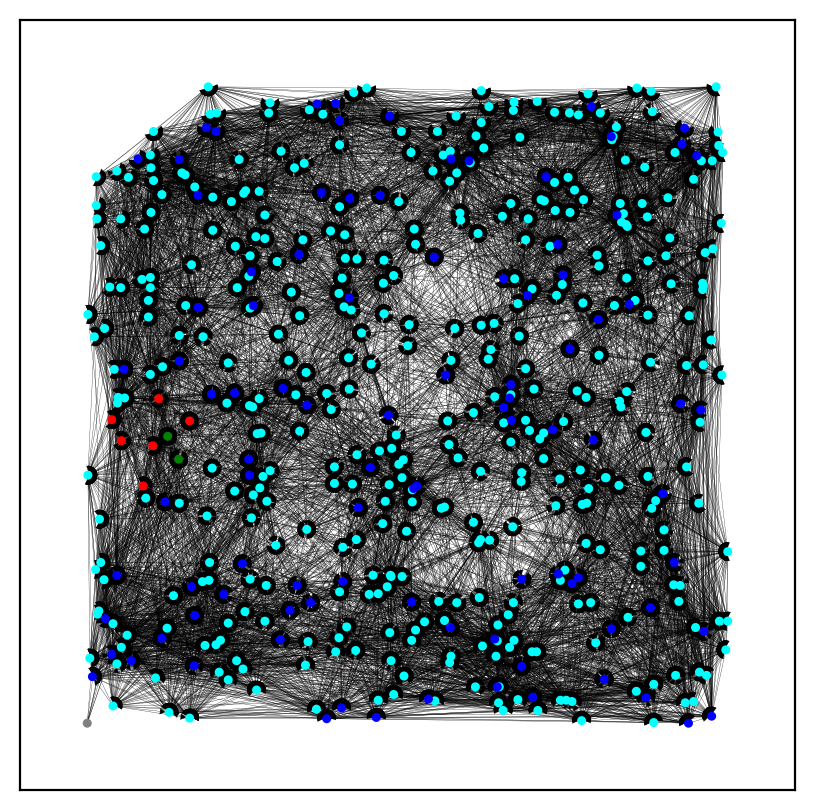

In [3]:
model = load_model(f'models/{model_name}')
# model.backup_iters = 40000
r_size = 10,25
ne = 400
ni = 100
ns = 30
n_stimulated = 7
model.reload_graph()
closest = model.find_n_nearest(0,n_stimulated)
G = model.get_graph()
highlight_nodes = [ne+ni, 0, *closest]
colors = []
for i in model.neurons.keys():
    colors.append(model[i].color)
print(G.number_of_nodes(), G.number_of_edges())
pos=nx.get_node_attributes(G,'pos')
print(highlight_nodes)
plt.figure(dpi=200, figsize=(5, 5))
nx.draw_networkx(G, pos, node_size=5, width=.1, arrowsize=5, node_color=colors, with_labels=False, font_size=6, font_color='green', font_weight=10)

In [10]:
model.get_incoming_synapses(120)

8000
Drawing raster


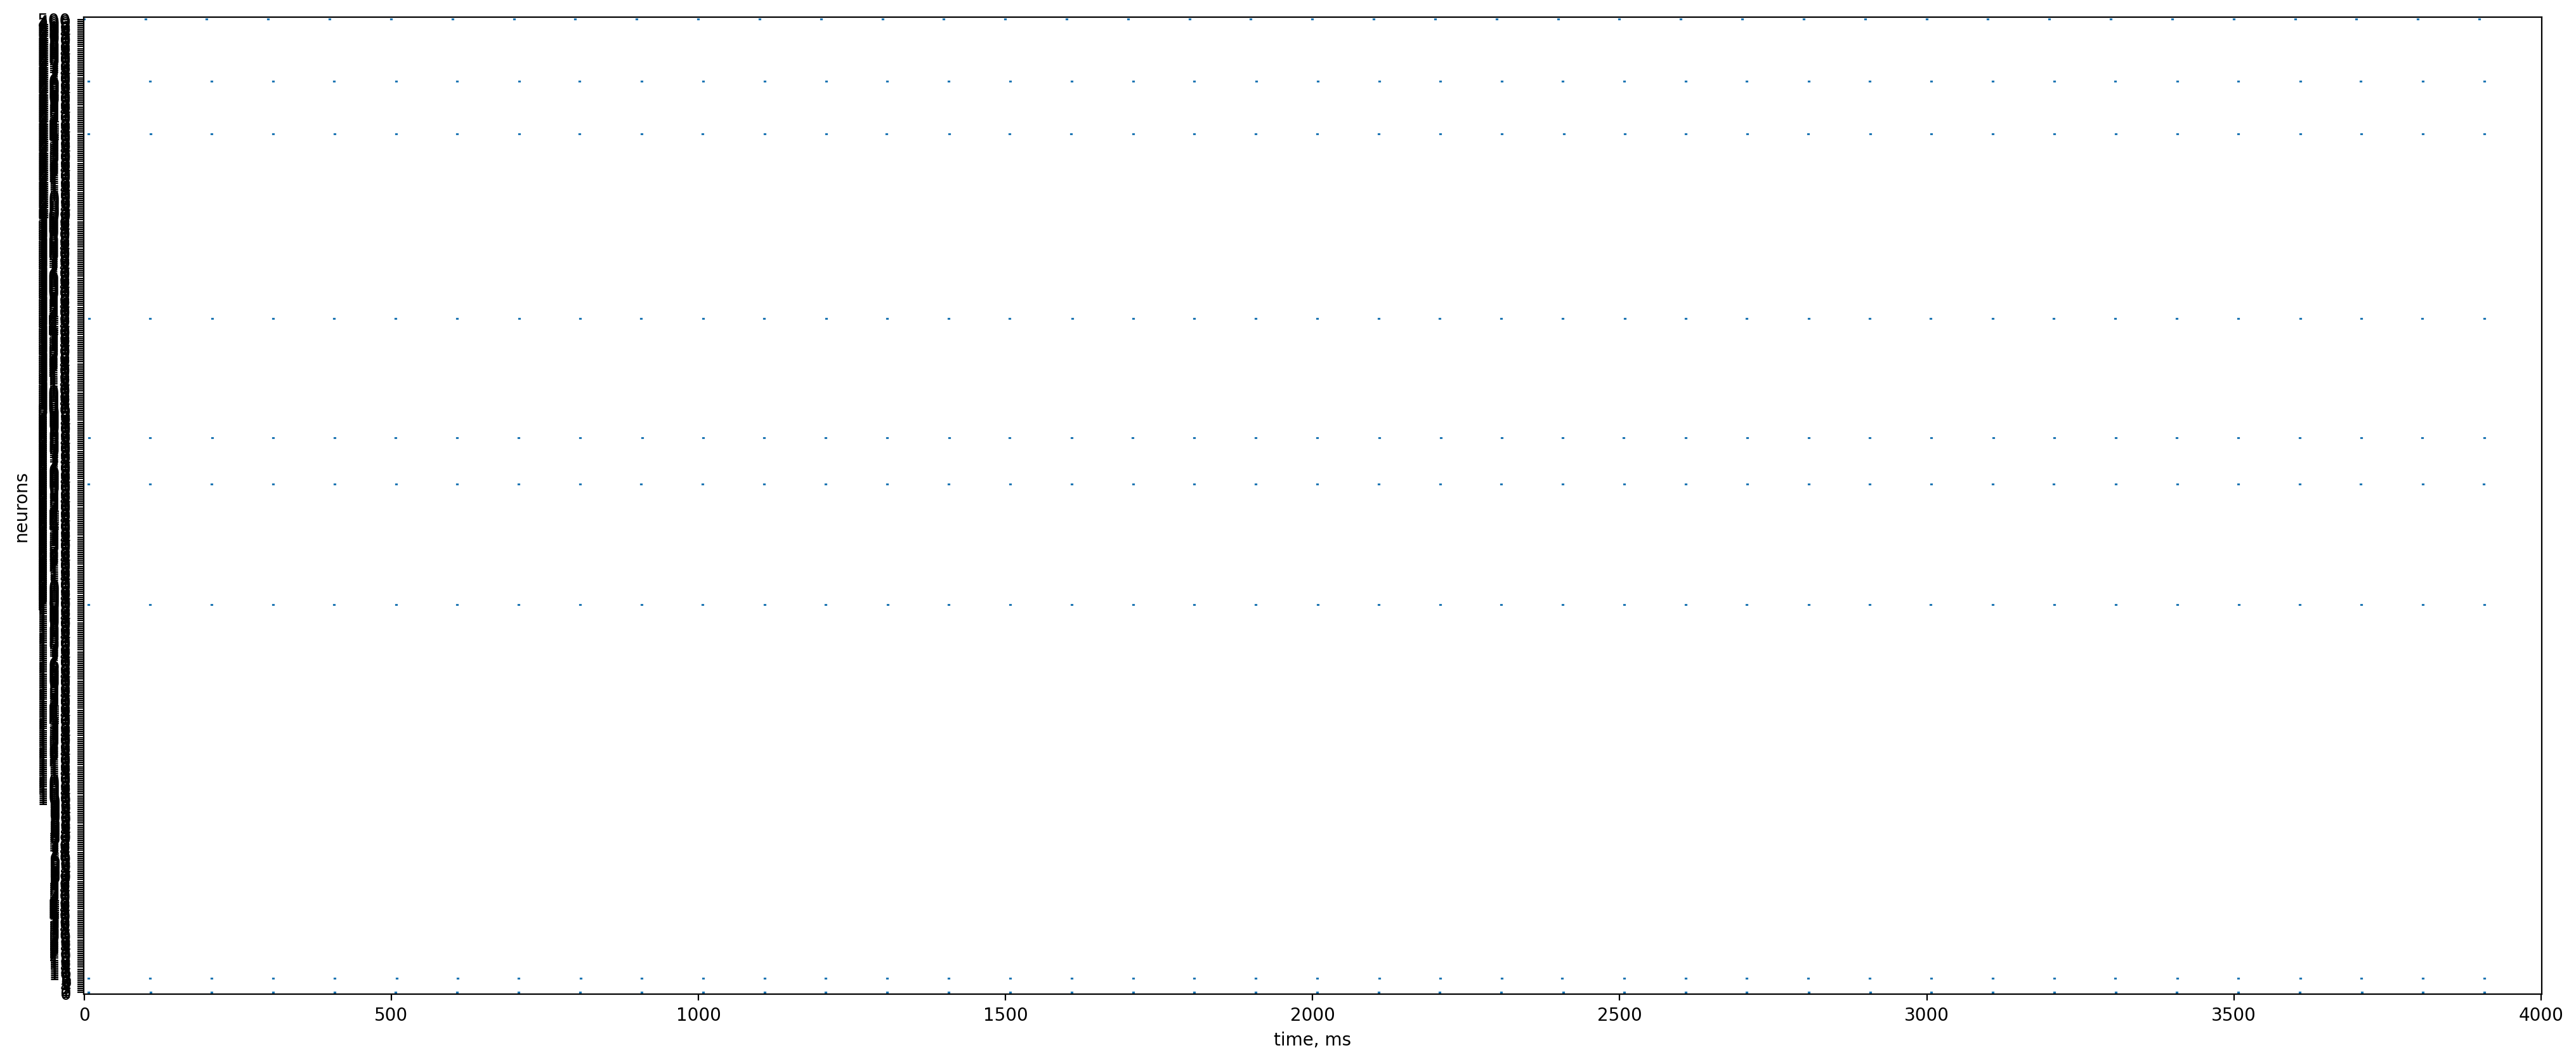

In [4]:
gath = Gatherer(model)
t_ms = 4000
t_steps = int(t_ms / res)
print(t_steps)
model.set_scale(.7)
model.set_noise(.6)
input_scale = 7
keep_scale(input_scale,0, model.obj0)
for i in range(t_steps):
    model.tick(freeze_delays=True)
    gath.gather_spikes_only()
gath.draw_raster(t_ms, fheight=r_size[0], fwidth=r_size[1])
# t_ms = 4000
# t_steps = int(t_ms / res)
# gath = Gatherer(model)
# model.set_scale(2.4)
# model.set_noise(.7)
# keep_scale(input_scale,0, model.obj0)
# for i in range(t_steps):
#     model.tick(freeze_delays=True)
#     gath.gather_spikes_only()
# gath.draw_raster(t_ms, fheight=r_size[0], fwidth=r_size[1])

In [3]:
print(model.syn_by_edge[500,0].resolution, model[0].resolution)

0.5 0.5


In [ ]:
# gath = Gatherer(model)
t_ms = 500000
t_steps = int(t_ms / res)
model.set_rule_to_all('pair_stdp') #stdp
# for i in model.syn_by_edge.keys(): #delayed
#     model.syn_by_edge[i].d_lr *=1
#     model.syn_by_edge[i].b = 8
# model.set_scale(1.)
# model.set_d_lr(100)
for i in range(t_steps):
    model.tick(freeze_delays=False)
    gath.gather_spikes_only()
print('Simulation is complete, drawing raster')
gath.draw_raster(t_ms, fheight=r_size[0], fwidth=r_size[1])
model.update_version()
save_model(model, f'models/{model_name}')

In [ ]:
gath = Gatherer(model)
t_ms = 4000
t_steps = int(t_ms / res)
model.set_scale(1.7)
model.set_noise(.6)
input_scale = 7
keep_scale(input_scale,0, model.obj0)
for i in range(t_steps):
    model.tick(freeze_delays=True)
    gath.gather_spikes_only()
gath.draw_raster(t_ms, fheight=r_size[0], fwidth=r_size[1])
# t_ms = 4000
# t_steps = int(t_ms / res)
# gath = Gatherer(model)
# model.set_scale(2.4)
# model.set_noise(.7)
# keep_scale(input_scale,0, model.obj0)
# for i in range(t_steps):
#     model.tick(freeze_delays=True)
#     gath.gather_spikes_only()
# gath.draw_raster(t_ms, fheight=r_size[0], fwidth=r_size[1])

In [ ]:
gath = Gatherer(model)
t_ms = 40000
t_steps = int(t_ms / res)
# model.set_scale(1.2)
# model.set_d_lr(.3)
# model.set_scale(4.8)
# model.set_noise(0.15)
for i in range(t_steps):
    model.tick(freeze_delays=True)
    gath.gather_spikes_only()
gath.draw_raster(t_ms)

In [ ]:
gath = Gatherer(model)
t_ms = 2000
t_steps = int(t_ms / res)
model.set_noise(0)
model.set_scale(1.2)
# model.set_d_lr(.3)
# model.set_scale(0)
for i in range(t_steps):
    model.tick(freeze_delays=True)
    gath.gather_spikes_only()
gath.draw_raster(t_ms)

In [ ]:
# t_ms = 30000
# t_steps = int(t_ms / res)
# # model.set_scale(1.)
# # model.set_d_lr(1)
# for i in range(t_steps):
#     model.tick(freeze_delays=False)

In [ ]:
gath = Gatherer(model)
t_ms = 60000
t_steps = int(t_ms / res)
# model.set_scale(3)
# model.set_d_lr(.3)
for i in range(t_steps):
    model.tick(freeze_delays=False)
    gath.gather_spikes_only()
gath.draw_raster(t_ms)

In [ ]:
gath = Gatherer(model)
t_ms = 1000
t_steps = int(t_ms / res)
# model.set_scale(1.2)
# model.set_d_lr(.3)
for i in range(t_steps):
    model.tick(freeze_delays=True)
    gath.gather_spikes_only()
gath.draw_raster(t_ms)


In [ ]:
gath = Gatherer(model)
t_ms = 1000
t_steps = int(t_ms / res)
model.set_scale(3.5)
model.set_noise(0)
for i in range(t_steps):
    model.tick(freeze_delays=True)
    gath.gather_spikes_only()
gath.draw_raster(t_ms)


In [ ]:
gath = Gatherer(model)
t_ms = 30000
t_steps = int(t_ms / res)
model.set_scale(3.1)
model.set_noise(0)
# model.set_d_lr(1)
for i in range(t_steps):
    model.tick(freeze_delays=False)
    gath.gather_spikes_only()
gath.draw_raster(t_ms)

In [ ]:
gath = Gatherer(model)
t_ms = 200
t_steps = int(t_ms / res)
model.set_scale(0)

# model.set_d_lr(.3)
model.set_noise(0)
for i in range(t_steps):
    model.tick(freeze_delays=True)
#     gath.gather_spikes_only()
# gath.draw_raster(t_ms)

In [ ]:
gath = Gatherer(model)
t_ms = 2000
t_steps = int(t_ms / res)
model.set_scale(5.2)
model[50].awaiting_time=150
# model.set_d_lr(.3)
model.set_noise(0)
for i in range(t_steps):
    model.tick(freeze_delays=True)
    gath.gather_spikes_only()
gath.draw_raster(t_ms)

In [ ]:
delays = []
for i in model.syn_by_edge.keys():
    delays.append(model.syn_by_edge[i].delay)
delays = np.array(delays)
delays = np.sort(delays)

In [ ]:
plt.plot(delays)

In [ ]:
model.add_note('m40e10i5s_g3-5n1-3, shows decent sync, starting conditions: random delay, 50k msec, d_lr=100')

In [ ]:
# save_model(model, 'models/m40e10i5s_g3-5n1-3')

In [ ]:
model = load_model('models/m40e10i5s_g3-5n1-3')
gath = Gatherer(model)
t_ms = 2000
t_steps = int(t_ms / res)
model.set_scale(0)
model[50].refresh_time = 4000
for i in range(t_steps):
    model.tick(freeze_delays=True)
    gath.gather_spikes_only()
gath.draw_raster(t_ms, fheight=5, fwidth=15, dpi=200)

In [ ]:
gath = Gatherer(model)
t_ms = 20000
t_steps = int(t_ms / res)
model.set_scale(4.8)
model.set_noise(.4)
model[50].refresh_time = 4000
for i in range(t_steps):
    model.tick(freeze_delays=True)
    gath.gather_spikes_only()
gath.draw_raster(t_ms, fheight=7, fwidth=15, dpi=200)

In [ ]:
gath.draw_raster(t_ms, fheight=7, fwidth=20, dpi=200)

In [ ]:
gath_r = Gatherer(model_r)
t_ms = 40000
t_steps = int(t_ms / res)
# model.set_scale(1.2)
# model.set_d_lr(.3)
print(model_r)
model_r.set_scale(3.5)
model_r.set_noise(1.3)
for i in range(t_steps):
    model_r.tick(freeze_delays=True)
    gath_r.gather_spikes_only()
gath_r.draw_raster(t_ms)

In [ ]:
random.randint(1,199)
model_r = load_model('models/m40e10i5s_g3-5n1-3')
for i in model_r.syn_by_edge.keys():
    model_r.syn_by_edge[i].delay = random.randint(1,1990)
    print(model_r.syn_by_edge[i].delay, random.randint(1,1990))